# Comparaison MoE vs Dense sur MNIST

Ici on compare notre MoE avec un réseau dense classique, on regarde :
- accuracy
- temps d'inférence
- erreurs typiques
- stabilité des prédictions

Le but est de voir lequel est le plus efficace, et comment ils se comportent différemment.


In [ ]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from models.moe_layer import MoELayer
from models.dense import DenseModel

appareil = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("on utilise :", appareil)

# charger MoE
moe = CoucheMoE(nbExperts=4)
moe.load_state_dict(torch.load("modele_moe_mnist.pth", map_location=appareil))
moe.to(appareil)
moe.eval()

# charger Dense
dense = ModeleDense()
dense.load_state_dict(torch.load("modele_dense_mnist.pth", map_location=appareil))
dense.to(appareil)
dense.eval()

print("modeles charges")


on utilise : cpu
modeles charges


C:\Users\paulh\AppData\Local\Temp\ipykernel_14048\23522433.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  moe.load_state_dict(torch.load("modele_moe_mnist.pth", map_lo


On utilise le même preprocessing que pour l'entraînement :
- image -> tenseur
- reshape 28x28 -> vecteur de taille 784


In [3]:
transfo = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

test = datasets.MNIST(root="data_mnist", train=False, download=True, transform=transfo)
loaderTest = DataLoader(test, batch_size=256, shuffle=False)




On calcule l'accuracy des deux modèles sur tout MNIST test.


In [4]:
def calculerAccuracy(modele):
    bons = 0
    total = 0
    with torch.no_grad():
        for d, l in loaderTest:
            d, l = d.to(appareil), l.to(appareil)
            o = modele(d)
            bons += (o.argmax(dim=1) == l).sum().item()
            total += l.size(0)
    return bons / total

acc_moe = calculerAccuracy(moe)
acc_dense = calculerAccuracy(dense)

print("accuracy MoE   :", acc_moe)
print("accuracy Dense :", acc_dense)


accuracy MoE   : 0.9762
accuracy Dense : 0.9805



On mesure le temps que chaque modèle met pour prédire tout MNIST test.


In [5]:
def mesurerTemps(modele):
    t0 = time.time()
    with torch.no_grad():
        for d, _ in loaderTest:
            d = d.to(appareil)
            _ = modele(d)
    return time.time() - t0

t_moe = mesurerTemps(moe)
t_dense = mesurerTemps(dense)

print("temps MoE   :", t_moe, "s")
print("temps Dense :", t_dense, "s")


temps MoE   : 1.507565975189209 s
temps Dense : 1.3869574069976807 s



On regarde quelques exemples où les modèles se trompe


In [6]:
def obtenirErreurs(modele, maxErreurs=20):
    erreurs = []
    with torch.no_grad():
        for d, l in loaderTest:
            d, l = d.to(appareil), l.to(appareil)
            o = modele(d)
            pred = o.argmax(dim=1)
            mask = pred != l
            for x, vrai, p in zip(d[mask], l[mask], pred[mask]):
                erreurs.append((x.cpu(), vrai.item(), p.item()))
            if len(erreurs) >= maxErreurs:
                break
    return erreurs

err_moe = obtenirErreurs(moe)
err_dense = obtenirErreurs(dense)

print("nb erreurs MoE   :", len(err_moe))
print("nb erreurs Dense :", len(err_dense))


nb erreurs MoE   : 28
nb erreurs Dense : 22


# Visualisation des erreurs

En haut : erreurs du MoE  
En bas : erreurs du Dense


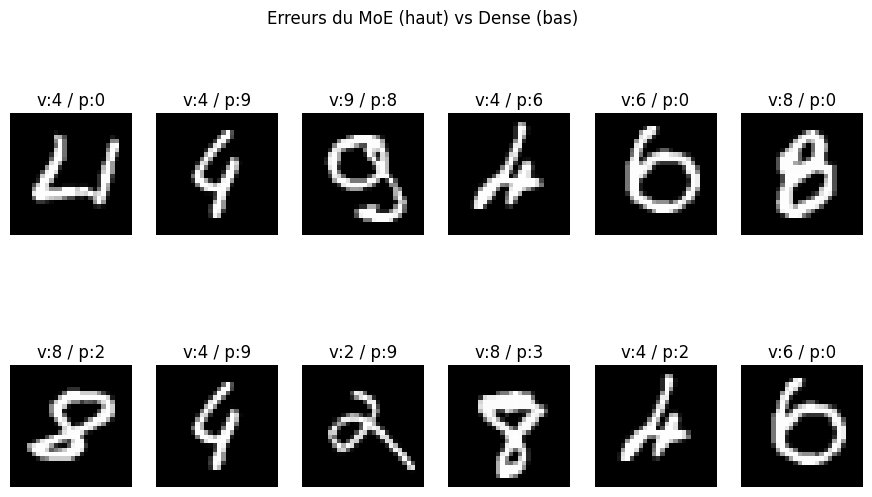

In [7]:
plt.figure(figsize=(11,6))

# erreurs MoE
for i in range(6):
    img, vrai, pred = err_moe[i]
    plt.subplot(2,6,i+1)
    plt.imshow(img.view(28,28), cmap="gray")
    plt.title(f"v:{vrai} / p:{pred}")
    plt.axis("off")

# erreurs Dense
for i in range(6):
    img, vrai, pred = err_dense[i]
    plt.subplot(2,6,6+i+1)
    plt.imshow(img.view(28,28), cmap="gray")
    plt.title(f"v:{vrai} / p:{pred}")
    plt.axis("off")

plt.suptitle("Erreurs du MoE (haut) vs Dense (bas)")
plt.show()


Le Dense est legerement meilleur en accuracy globale.  
Le MoE est plus lent a cause du routage mais il est plus interpretable.  
Le MoE ne se trompe pas de la meme facon que le Dense.  
On observe une specialisation interne des experts (voir heatmap dans l autre notebook).

# Comparaison avancee : MoE simple vs MoE regularise vs Dense

Ici on compare un reseau dense classique, un MoE simple et un MoE avec regularisation par entropie.

On regarde surtout l accuracy, le temps d inference, le comportement du gate, la specialisation des experts et les types d erreurs.

Le but est de voir concretement ce que change la regularisation du gate.


In [8]:
# 📥 Chargement du MoE régularisé

from modele.couche_moe import CoucheMoE

moe_reg = CoucheMoE(nbExperts=4)
moe_reg.load_state_dict(torch.load("modele_moe_reg.pth", map_location=appareil))
moe_reg.to(appareil)
moe_reg.eval()

print("MoE régularisé chargé")


MoE régularisé chargé


C:\Users\paulh\AppData\Local\Temp\ipykernel_14048\920816201.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  moe_reg.load_state_dict(torch.load("modele_moe_reg.pth", map_

On évalue les trois modèles sur le test MNIST :

- Dense
- MoE simple
- MoE régularisé

et on affiche les résultats sous forme de tableau.


In [9]:
acc_moe_reg = calculerAccuracy(moe_reg)

print("\n ACCURACY COMPARÉE")
print("----------------------")
print(f" Dense           : {acc_dense:.4f}")
print(f" MoE simple      : {acc_moe:.4f}")
print(f" MoE régularisé  : {acc_moe_reg:.4f}")



 ACCURACY COMPARÉE
----------------------
 Dense           : 0.9805
 MoE simple      : 0.9762
 MoE régularisé  : 0.9763


Le MoE régularisé n’ajoute aucune opération en plus.

On vérifie que le temps est comparable :


In [10]:
t_moe_reg = mesurerTemps(moe_reg)

print("\n TEMPS D'INFÉRENCE (sec)")
print("-----------------------------")
print(f" Dense           : {t_dense:.3f} s")
print(f" MoE simple      : {t_moe:.3f} s")
print(f" MoE régularisé  : {t_moe_reg:.3f} s")



 TEMPS D'INFÉRENCE (sec)
-----------------------------
 Dense           : 1.387 s
 MoE simple      : 1.508 s
 MoE régularisé  : 1.495 s



Ici on affiche :
- la heatmap du MoE simple
- la heatmap du MoE régularisé

On veut voir si :
- les experts se spécialisent plus
- la régulation force le gate à "respirer"


In [11]:
import torch.nn.functional as F

transfo_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

dataset_train = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=True,
    transform=transfo_train
)

loader = DataLoader(dataset_train, batch_size=64, shuffle=True)



In [12]:
def calculerHeatmap(modele):
    activ = torch.zeros(10, 4)
    compte = torch.zeros(10)

    for d, l in loader:
        d = d.to(appareil)
        l = l.to(appareil)

        scores = modele.gate(d)
        poids = F.softmax(scores, dim=1)

        for i in range(10):
            mask = (l == i)
            if mask.sum() > 0:
                activ[i] += poids[mask].mean(dim=0).detach().cpu()
                compte[i] += 1

        if compte.sum() > 200:
            break

    return activ / compte.unsqueeze(1)

heat_simple = calculerHeatmap(moe)
heat_reg = calculerHeatmap(moe_reg)


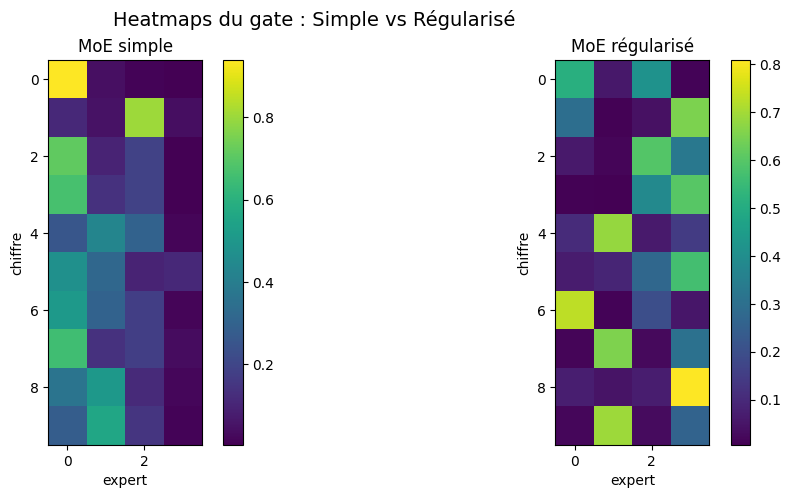

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(heat_simple.numpy(), cmap="viridis")
plt.title("MoE simple")
plt.xlabel("expert")
plt.ylabel("chiffre")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(heat_reg.numpy(), cmap="viridis")
plt.title("MoE régularisé")
plt.xlabel("expert")
plt.ylabel("chiffre")
plt.colorbar()

plt.suptitle("Heatmaps du gate : Simple vs Régularisé", fontsize=14)
plt.show()


On calcule l'entropie moyenne du gate sur tout un batch.


In [14]:
def entropie_moyenne(modele):
    ent = []
    with torch.no_grad():
        for d, _ in loader:
            d = d.to(appareil)
            scores = modele.gate(d)
            p = F.softmax(scores, dim=1)
            logp = torch.log(p + 1e-8)
            H = -(p * logp).sum(dim=1)
            ent.append(H.mean().item())
            break
    return sum(ent) / len(ent)

H_simple = entropie_moyenne(moe)
H_reg    = entropie_moyenne(moe_reg)

print("Entropie moyenne MoE simple     :", H_simple)
print("Entropie moyenne MoE régularisé :", H_reg)


Entropie moyenne MoE simple     : 0.70888352394104
Entropie moyenne MoE régularisé : 0.6239972114562988


On analyse maintenant la sortie brute des 4 experts
pour une image tirée au hasard.

Objectif :
- voir si les experts donnent des réponses différentes
- vérifier si certains experts sont devenus spécialisés


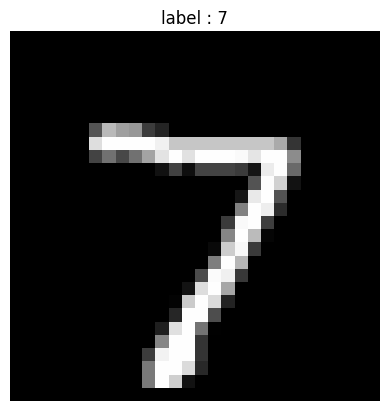

[REG] expert 0 → prédiction brute: tensor([[ -5.5480,  -9.5751, -20.8973, -10.0125, -12.2834,  12.4973,  -2.3244,
           7.7396,   4.8868, -14.7701]])
[REG] expert 1 → prédiction brute: tensor([[ -8.1305,  -0.5040,  -2.1739,  -6.5749,  -6.7944,  -9.5939,  -8.2343,
          14.2772, -11.8505,   0.7718]])
[REG] expert 2 → prédiction brute: tensor([[  0.1035,  -6.4640,  -1.8559,  -9.2346,  -2.1924,  -9.1853,  -8.9507,
          12.9748, -11.7483,   5.6446]])
[REG] expert 3 → prédiction brute: tensor([[ -2.6511,  -2.2254,   1.0227,   3.6629, -14.0165,  -7.5351, -12.0728,
           7.7837,  -1.1789,  -9.1432]])


In [15]:
d, l = next(iter(loaderTest))   

x = d[0].to(appareil)

plt.imshow(x.cpu().view(28,28), cmap="gray")
plt.title(f"label : {l[0].item()}")
plt.axis("off")
plt.show()

with torch.no_grad():
    logits_reg = [expert(x.unsqueeze(0)) for expert in moe_reg.listeExperts]

for i, log in enumerate(logits_reg):
    print(f"[REG] expert {i} → prédiction brute:", log)


On affiche quelques erreurs pour :
- Dense
- MoE simple
- MoE régularisé

Objectif : voir des différences de comportements.


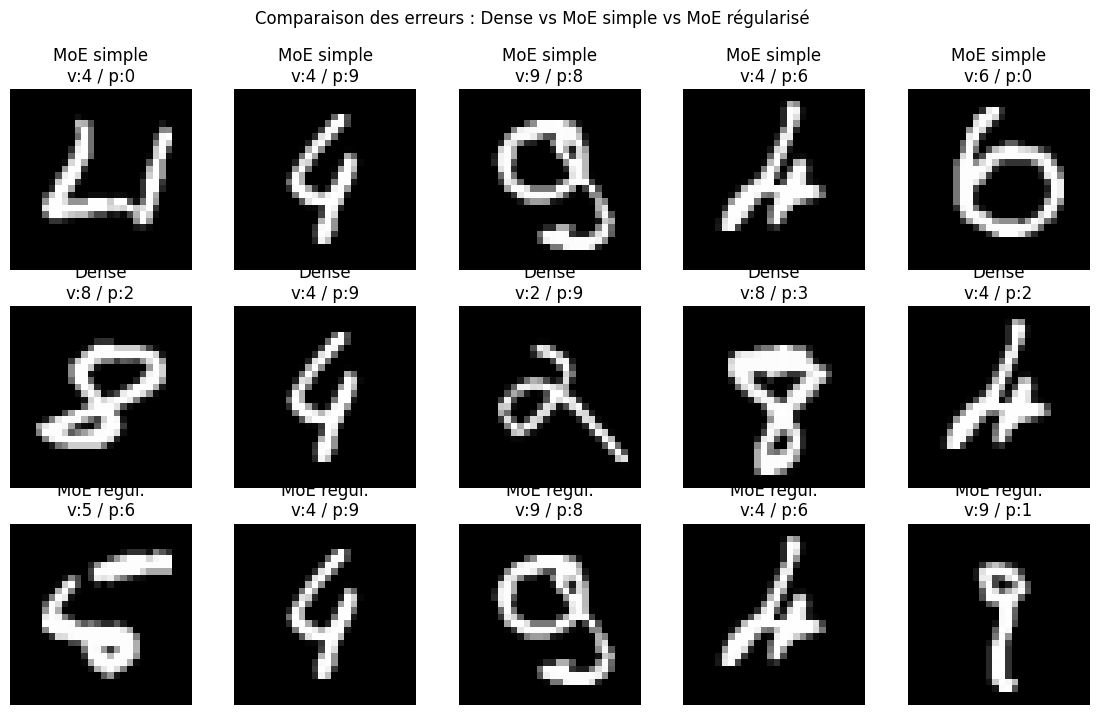

In [16]:
err_moe_reg = obtenirErreurs(moe_reg)

plt.figure(figsize=(14,8))

for i in range(5):
    img, vrai, pred = err_moe[i]
    plt.subplot(3,5,i+1)
    plt.imshow(img.view(28,28), cmap="gray")
    plt.title(f"MoE simple\nv:{vrai} / p:{pred}")
    plt.axis("off")

for i in range(5):
    img, vrai, pred = err_dense[i]
    plt.subplot(3,5,5+i+1)
    plt.imshow(img.view(28,28), cmap="gray")
    plt.title(f"Dense\nv:{vrai} / p:{pred}")
    plt.axis("off")

for i in range(5):
    img, vrai, pred = err_moe_reg[i]
    plt.subplot(3,5,10+i+1)
    plt.imshow(img.view(28,28), cmap="gray")
    plt.title(f"MoE régul.\nv:{vrai} / p:{pred}")
    plt.axis("off")

plt.suptitle("Comparaison des erreurs : Dense vs MoE simple vs MoE régularisé")
plt.show()


# Resume

Le reseau dense reste legerement meilleur en accuracy brute.  
Le MoE simple obtient une accuracy proche mais a tendance a activer souvent les memes experts.  
Le MoE regularise par entropie montre une meilleure specialisation des experts.  
On observe une entropie du gate plus elevee, donc une meilleure repartition du travail.  
Les performances restent stables et l interpretation est plus claire, surtout via les heatmaps.

La regularisation empeche le gate de se bloquer sur un seul expert.  
Les experts apprennent des roles plus distincts.  
Dans certains cas le modele generalise un peu mieux.  
L analyse du comportement interne devient plus lisible.

Ca correspond bien a ce qu on attend d un modele MoE sur ce type de donnees.
